## Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

feedback = pd.read_csv("feedback_features.csv")
master_df = pd.read_csv("master_dataset.csv")

## Customer Feedback KPIs

In [3]:
total_feedback = feedback["feedback_id"].nunique()

average_rating = feedback["rating"].mean()

positive_feedback = feedback["positive"].sum()

negative_feedback = feedback["negative"].sum()

positive_percentage = (positive_feedback / total_feedback) * 100

negative_percentage = (negative_feedback / total_feedback) * 100

In [4]:
print(f"Total Feedback : {total_feedback}")
print(f"Average Rating : {average_rating:.2f}")
print(f"Positive Feedback : {positive_feedback}")
print(f"Negative Feedback : {negative_feedback}")
print(f"Positive % : {positive_percentage:.2f}%")
print(f"Negative % : {negative_percentage:.2f}%")

Total Feedback : 5000
Average Rating : 3.34
Positive Feedback : 2524
Negative Feedback : 1078
Positive % : 50.48%
Negative % : 21.56%


## Rating Analysis

In [6]:
feedback["rating"].value_counts().sort_index()

rating
1     540
2     538
3    1398
4    1708
5     816
Name: count, dtype: int64

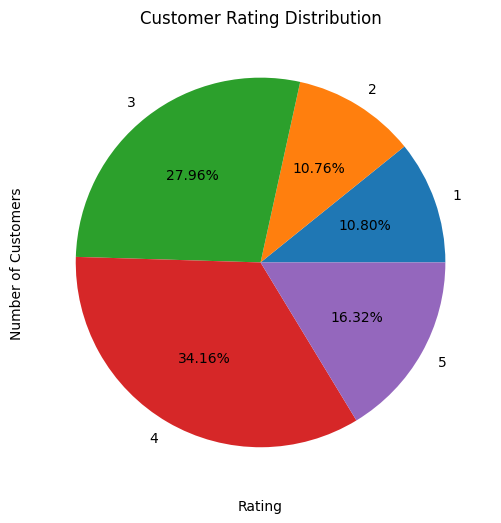

In [16]:
feedback["rating"].value_counts().sort_index().plot(kind="pie",autopct='%1.2f%%',figsize=(6,6))
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")
plt.show()

### Business Questions
- How are customer ratings distributed? Most common rating?
- Average rating?
- Percentage of 4 & 5-star ratings?
- Percentage of 1 & 2-star ratings?

### Observations
- The most common rating is 4 and followed by 3.
- Average rating is 3.34.
- Percentage of 4 & 5-star ratings are 34.16% and 16.32%.
- Percentage of 1 & 2-star ratings are 10.80% and 10.76%.

### Recommendations
Concentrate more on the feedbacks of Customers whose rating are 1 and 2.

## Sentiment Analysis

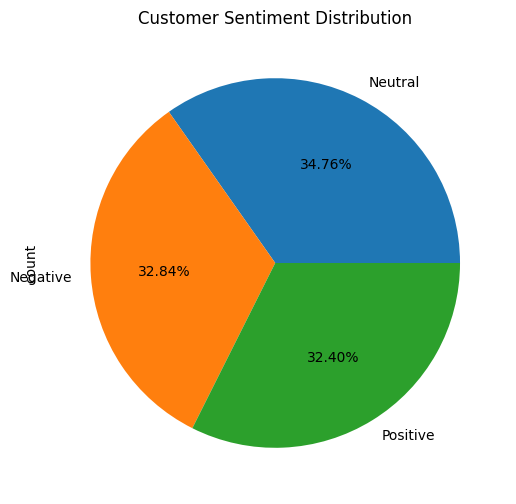

In [17]:
feedback["sentiment"].value_counts().plot(kind="pie",autopct="%1.2f%%",figsize=(6,6))
plt.title("Customer Sentiment Distribution")
plt.show()

### Business Questions
- Positive vs Negative sentiment?
- Neutral customer percentage?
- Which sentiment dominates?

### Observations
- Positive vs Negative sentiment is observed as 32.40% vs 32.84%.
- Neutral Customer Percentage is 34.76%.
- Neutral Sentiment dominates in this overall Distribution.

### Recommendations
Concentrate more on the feedbacks of Customers whose sentiments are both negative and neutral.

## Complaint Category Analysis

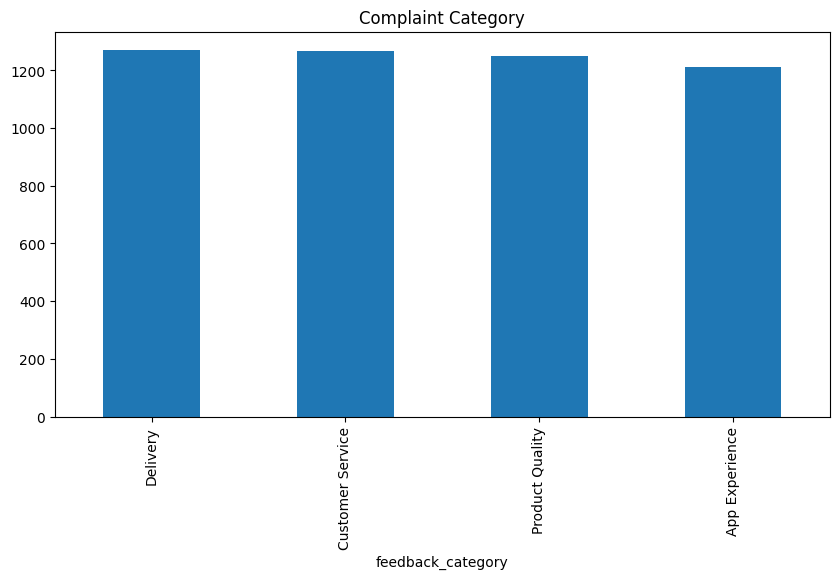

In [20]:
feedback['feedback_category'].value_counts().plot(kind='bar',figsize=(10,5))
plt.title("Complaint Category")
plt.show()

### Business Questions
- Most common complaint?
- Which operational issue appears frequently?
- Which complaints should be prioritized?

### Observations
- Most common Complaint is Delivery.
- Delivery related operational issue appears frequently.
- Both Delivery and Customer Service complaints should be prioritized.

### Recommendations
Concentrate more on the feedbacks of Customers whose complaints are both delivery and customer service related.

## Delivery vs Customer Rating Analysis

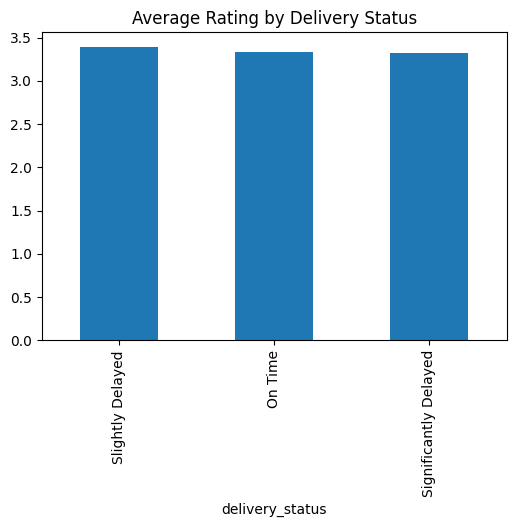

In [28]:
delivery_rating = master_df.groupby("delivery_status")["rating"].mean().sort_values(ascending=False)

delivery_rating.plot(kind="bar",figsize=(6,4))
plt.title("Average Rating by Delivery Status")
plt.show()

In [29]:
delivery_rating

delivery_status
Slightly Delayed         3.392478
On Time                  3.332565
Significantly Delayed    3.326572
Name: rating, dtype: float64

### Business Questions
- Does delivery performance affect customer ratings?
- Are delayed orders rated lower?
- Does on-time delivery improve satisfaction?

### Observations
- Yes, delivery performance affects customer ratings.
- Significantly delayed orders are rated lower.
- Comparatively, Yes On-time delivery improves satisfaction.

### Recommendations
Concentrate more on the significantly late delivery of orders which includes the staff allocation.

## Product Feedback Analysis

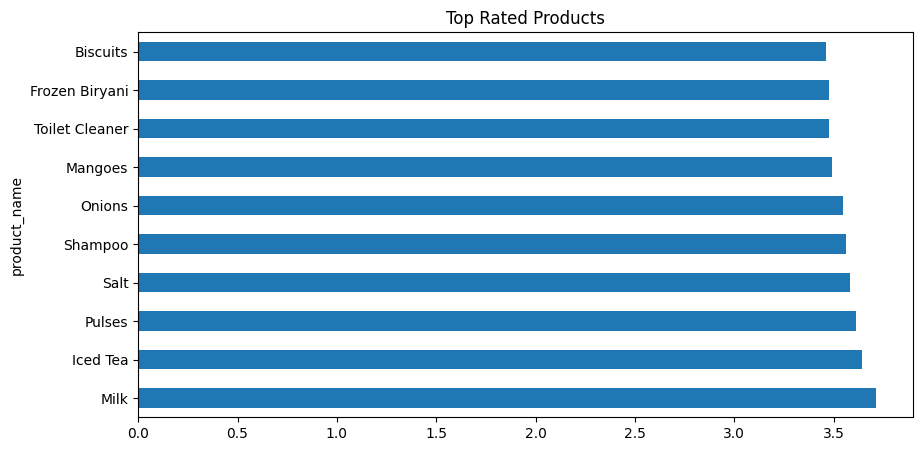

In [30]:
product_rating = (master_df.groupby("product_name")["rating"].mean().sort_values(ascending=False))

product_rating.head(10).plot(kind="barh",figsize=(10,5))
plt.title("Top Rated Products")
plt.show()

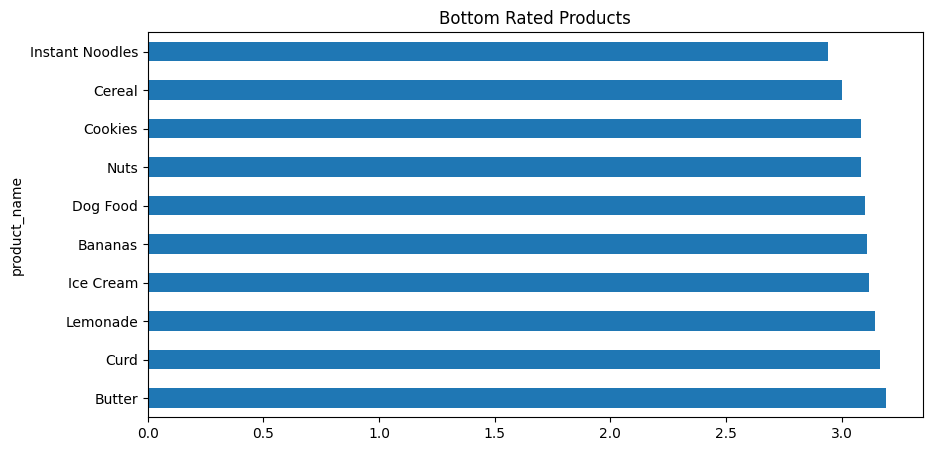

In [31]:
product_rating.tail(10).plot(kind="barh",figsize=(10,5))
plt.title("Bottom Rated Products")
plt.show()

### Business Questions
- Which products receive the highest and lowest ratings?
- Which products delight customers?
- Which products need quality improvements?

### Observations
- Milk receives the highest and Instant Noodles receives the lowest ratings.
- Milk, Iced Tea, Pulses products which delights customers.
- Instant Noodles, Cereal, Cookies products which need quality improvements.

### Recommendations
Concentrate more on the Bottom rated products and how to make changes in the product quality perspective.

## Customer Demographic Feedback Analysis

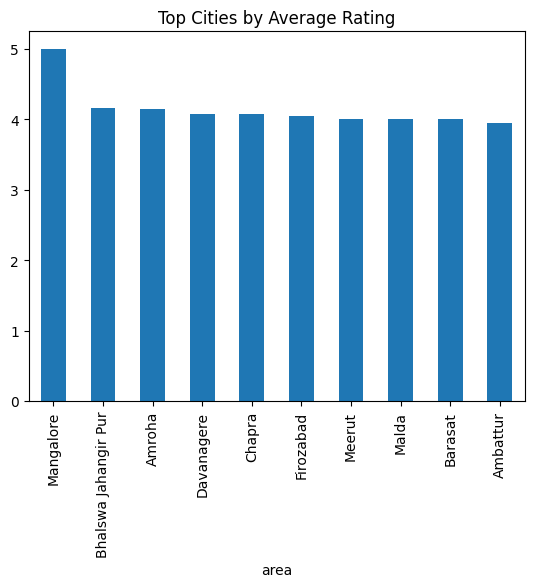

In [32]:
master_df.groupby("area")["rating"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Cities by Average Rating")
plt.show()

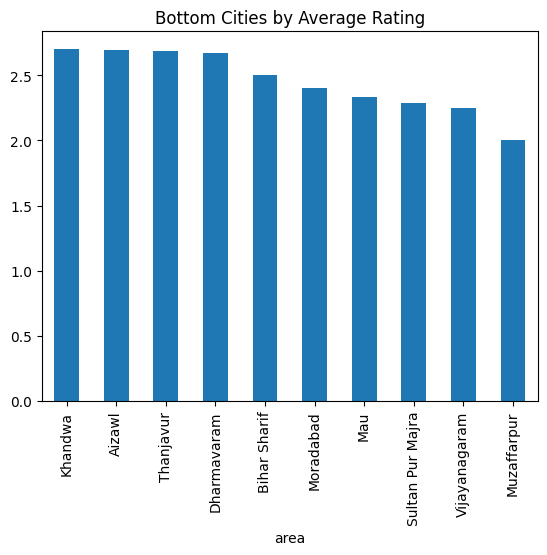

In [34]:
master_df.groupby("area")["rating"].mean().sort_values(ascending=False).tail(10).plot(kind="bar")
plt.title("Bottom Cities by Average Rating")
plt.show()

### Business Questions
- Which cities scored the highest ratings?
- Which cities require service improvement?

### Observations
- Mangalore city has scored the highest rating.
- All the observed cities in the Bottom like Muzaffarpur, Vijayanagaram,... require service improvement.

### Recommendations
Concentrate more on the Bottom rated areas and do service improvement.

## Correlation Analysis

In [35]:
master_df[
[
    "rating",
    "Delivery_Delay_Minutes",
    "Revenue",
    "quantity"
]
].corr()

,rating,Delivery_Delay_Minutes,Revenue,quantity
rating,1.000000,0.000170,-0.004560,0.001289
Delivery_Delay_Minutes,0.000170,1.000000,0.000547,0.017744
Revenue,-0.004560,0.000547,1.000000,0.540091
quantity,0.001289,0.017744,0.540091,1.000000


### Business Question
Does delivery delay affect ratings?

### Observation
Yes, delivery delay affects ratings but very slightly.

## Outlier Analysis

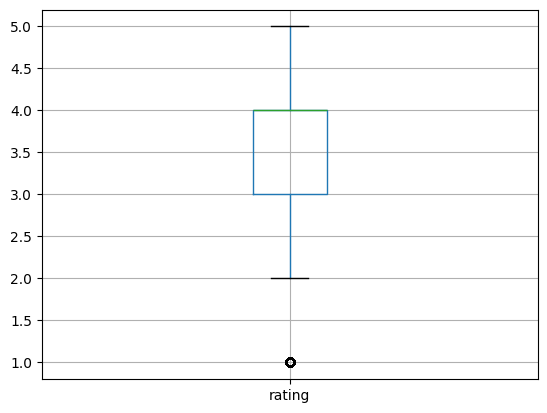

In [36]:
feedback.boxplot(column="rating")
plt.show()

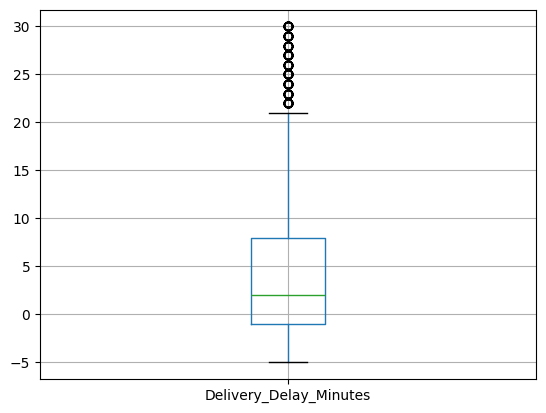

In [37]:
master_df.boxplot(column="Delivery_Delay_Minutes")
plt.show()

In [40]:
master_df['Delivery_Delay_Minutes'].max()

30.0

### Business Question
Extreme delays? Unusually low ratings?

### Observation
There are some extreme delays observed, but we have seen 1 rating as unusual but very less.

## Dashboard Requirements

### KPI Cards
- Total Feedback
- Average Rating
- Positive Feedback %
- Negative Feedback %
- Average Delivery Delay

### Charts
- Rating Distribution
- Sentiment Distribution
- Complaint Categories
- Rating by Product
- Rating by Area
- Rating vs Delivery Status

### Filters (Slicers)
- Product
- Area
- Rating
- Sentiment
- Delivery Status
- Date